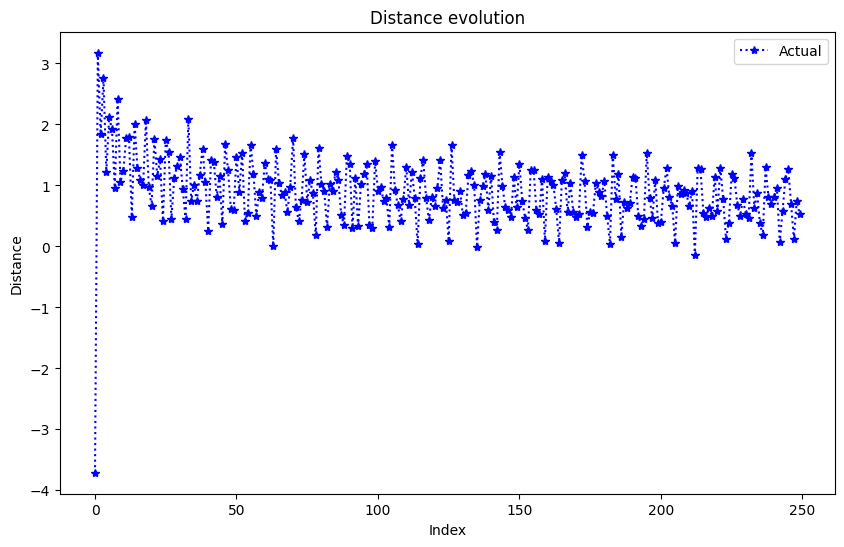

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


dataset = pd.read_csv("../dataset/riemann_features_v2.csv")

X = dataset.drop(columns=["distance"]).to_numpy()
y = dataset["distance"].to_numpy()

limit = 250
plt.figure(figsize=(10, 6))
plt.plot(range(len(y[:limit])), y[:limit], 'b:*', label='Actual')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Distance evolution')
plt.legend()
plt.show()

# Feature selection

Ensemble Feature Selection (ou Feature Selection by Rank Aggregation)
combinar rankings de múltiplos métodos para obter um ranking consensual mais robusto

Amostras: 100000 | Features: 14
Target (distance): mean=0.3745, std=0.2394



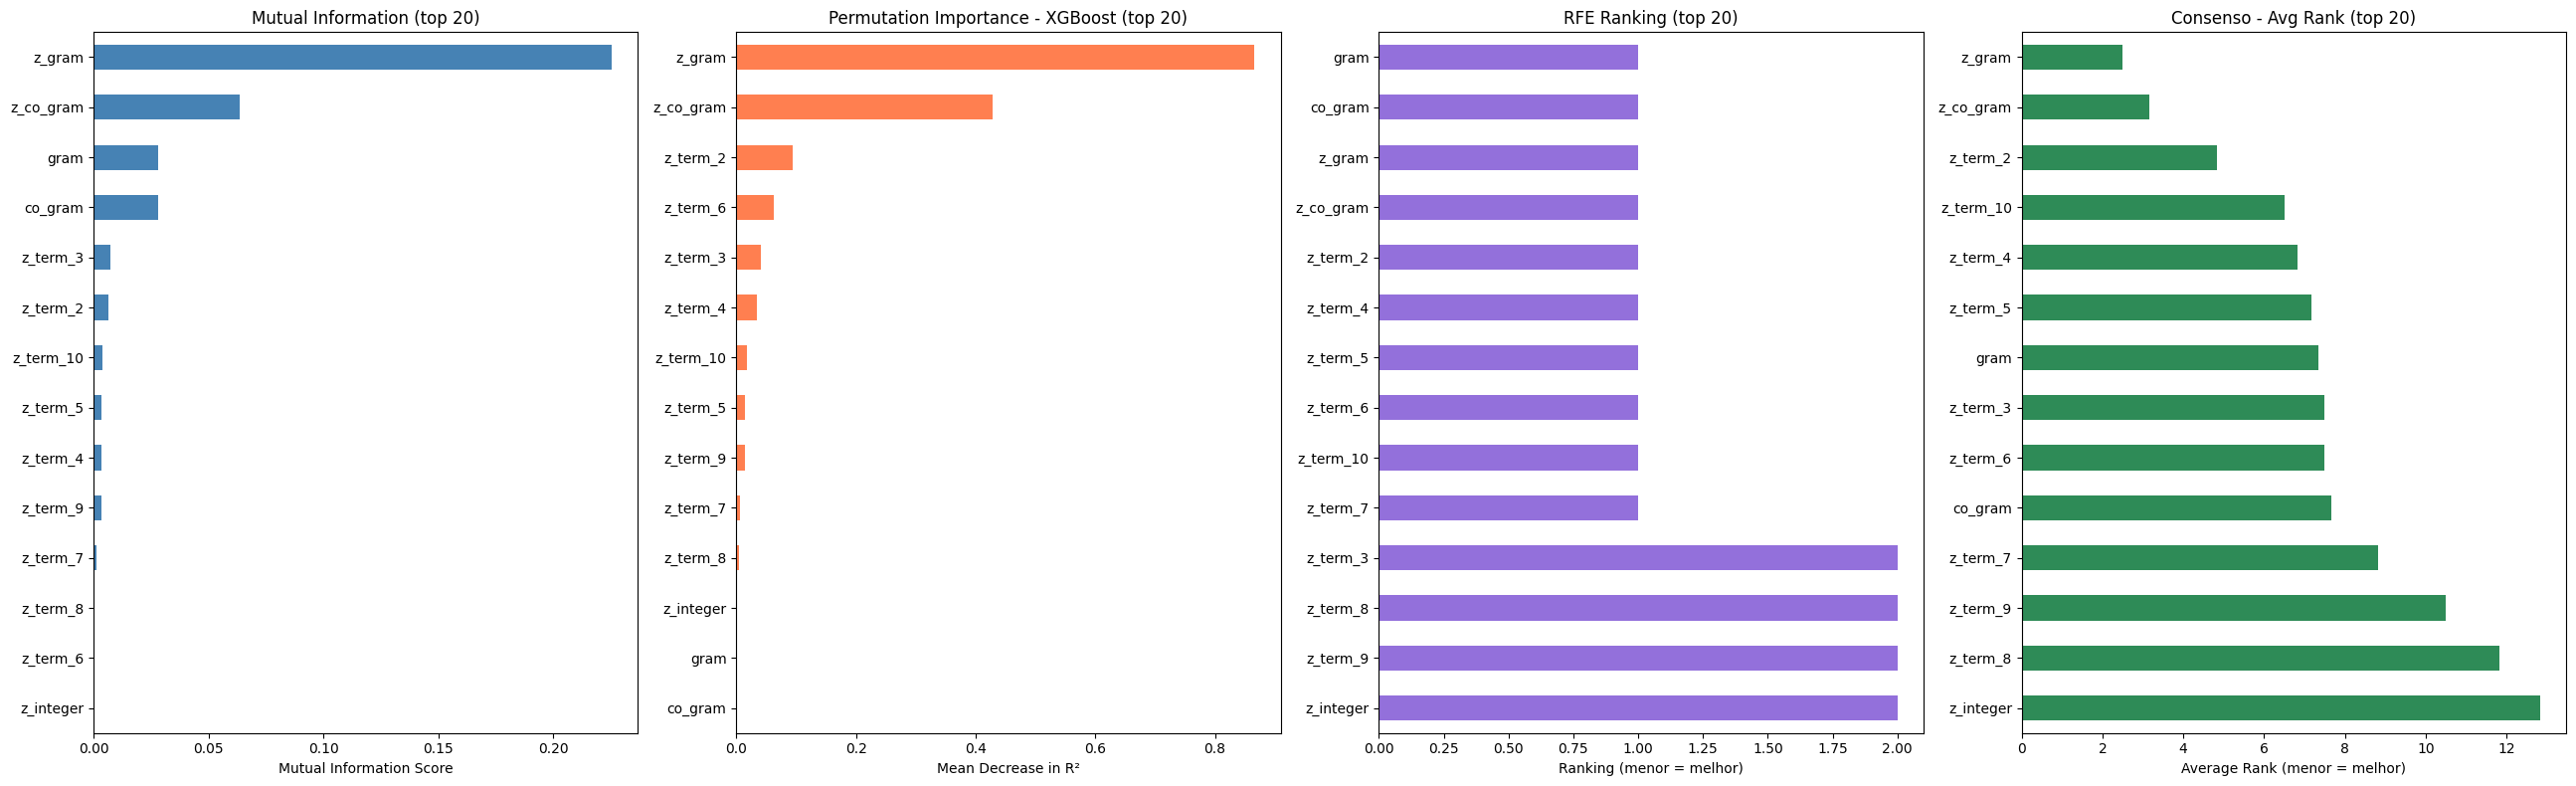


Salvos: selected_features.csv, feature_ranking_full.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features_v2.csv'

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]
features = X.columns.tolist()

# X = X[:2000]
# y = y[:2000]

split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

print(f"Amostras: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Target ({TARGET}): mean={y.mean():.4f}, std={y.std():.4f}\n")

mi = mutual_info_regression(X_tr, y_tr, random_state=42, n_neighbors=5)
mi = pd.Series(mi, index=features).sort_values(ascending=False)

xgb = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
xgb.fit(X_tr, y_tr)

perm = permutation_importance(xgb, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)


rfe_model = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
rfe = RFE(rfe_model, n_features_to_select=10, step=5)
rfe.fit(X_tr, y_tr)
rfe_ranking = pd.Series(rfe.ranking_, index=features).sort_values()

mi_ranks = mi.rank(ascending=False)
perm_ranks = perm_imp.rank(ascending=False)
rfe_ranks = rfe_ranking.rank(ascending=True)

consensus = pd.DataFrame({
    'MI': mi_ranks,
    'Permutation': perm_ranks,
    'RFE': rfe_ranks
})
consensus['avg_rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('avg_rank')

selected = consensus.head(10).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(26, 8))

mi.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information (top 20)')
axes[0].set_xlabel('Mutual Information Score')
axes[0].invert_yaxis()

perm_imp.head(20).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Permutation Importance - XGBoost (top 20)')
axes[1].set_xlabel('Mean Decrease in R²')
axes[1].invert_yaxis()

rfe_ranking.head(20).plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('RFE Ranking (top 20)')
axes[2].set_xlabel('Ranking (menor = melhor)')
axes[2].invert_yaxis()

consensus['avg_rank'].head(20).plot(kind='barh', ax=axes[3], color='seagreen')
axes[3].set_title('Consenso - Avg Rank (top 20)')
axes[3].set_xlabel('Average Rank (menor = melhor)')
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

pd.DataFrame({'feature': selected}).to_csv('../results/data_analysis_v2/selected_features.csv', index=False)
consensus.to_csv('../results/data_analysis_v2/feature_ranking_full.csv')
print(f"\nSalvos: selected_features.csv, feature_ranking_full.csv")

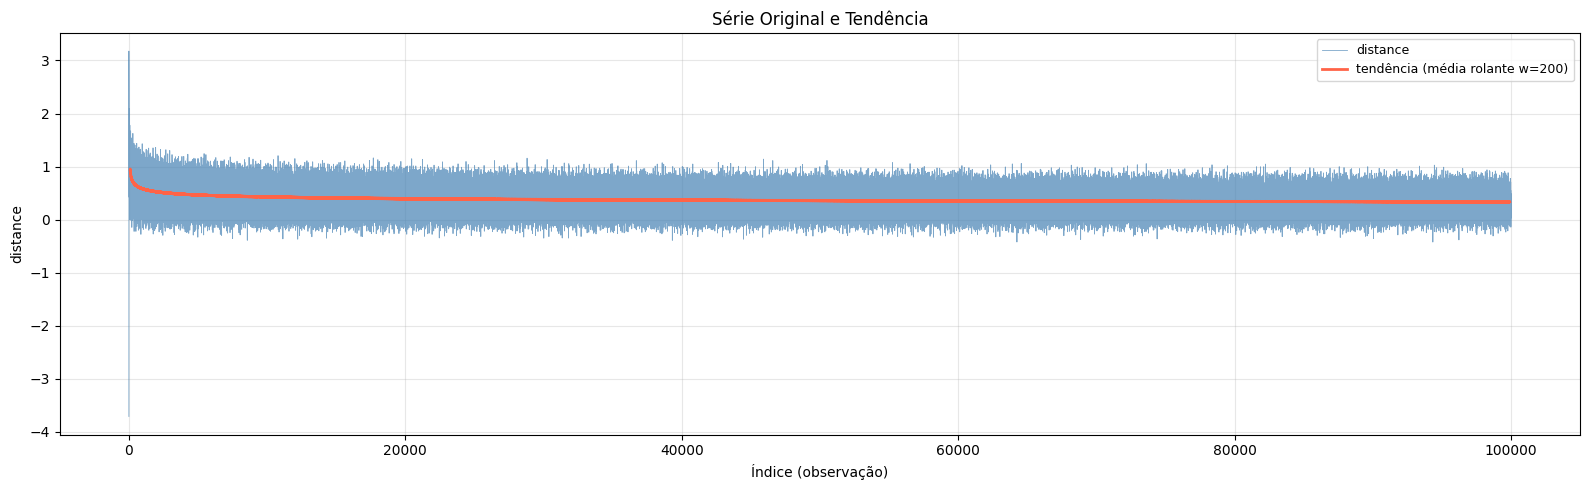

In [3]:
TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features_v2.csv'

df = pd.read_csv(DATA_PATH)
series = df[TARGET].copy()

window = 200
trend = series.rolling(window, center=True).mean()

plt.figure(figsize=(16, 5))

plt.plot(series, lw=0.6, alpha=0.7, color='steelblue', label='distance')
plt.plot(trend, color='tomato', lw=2, label=f'tendência (média rolante w={window})')
plt.title('Série Original e Tendência')
plt.xlabel('Índice (observação)')
plt.ylabel('distance')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/data_analysis_v2/trend.png', dpi=150, bbox_inches='tight')
plt.show()

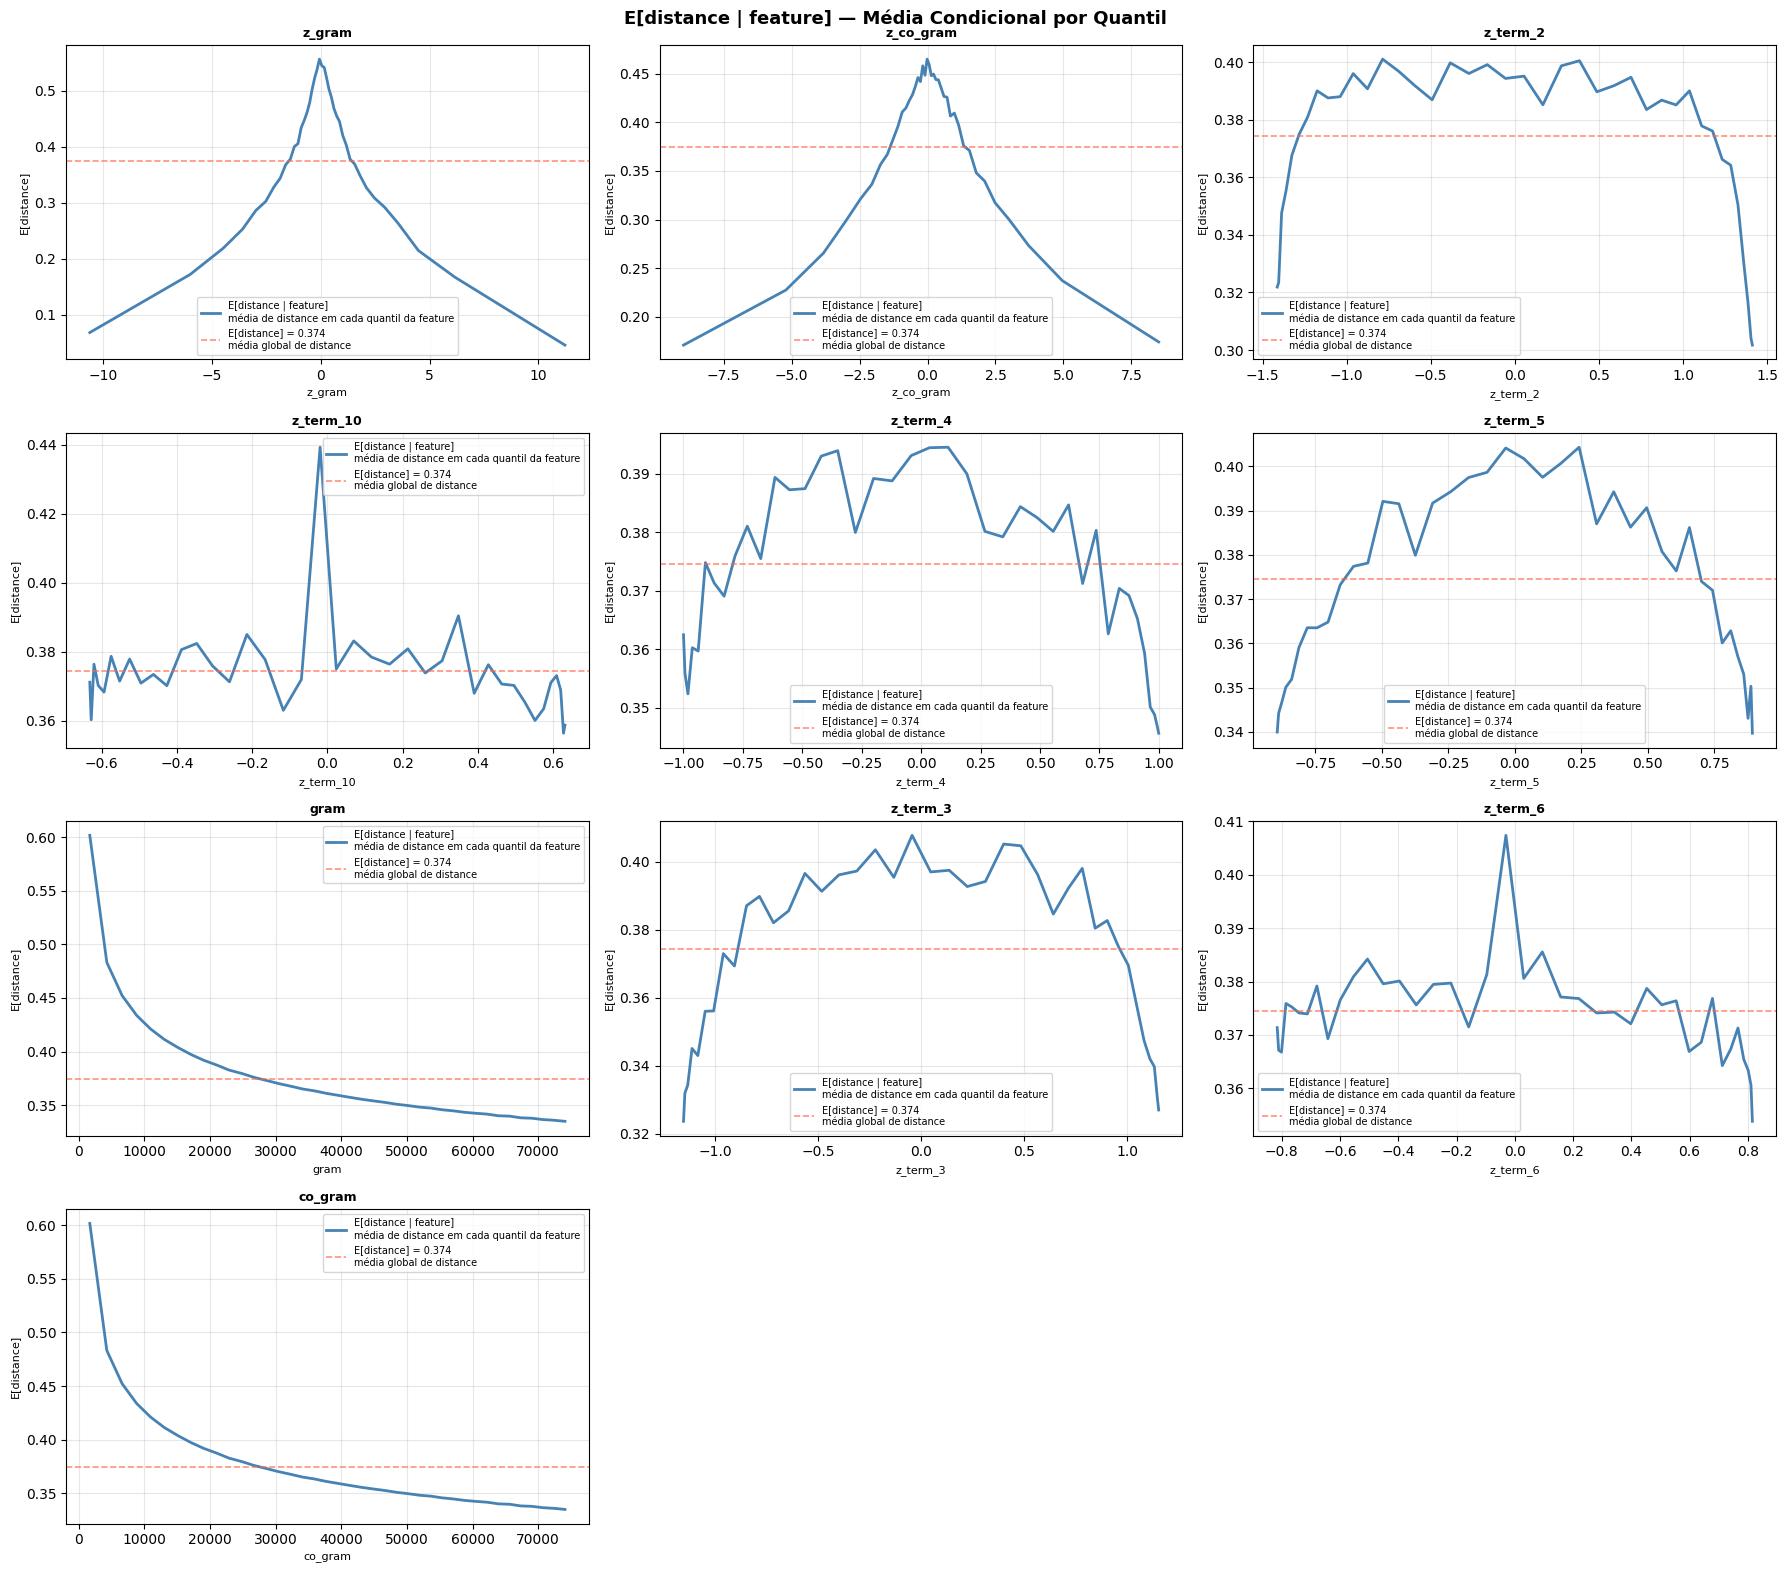

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features_v2.csv'
SELECTED_PATH = '../results/data_analysis_v2/selected_features.csv'

df = pd.read_csv(DATA_PATH)
selected = pd.read_csv(SELECTED_PATH)['feature'].tolist()
cols = selected + [TARGET]
df = df[cols].copy()

n_cols = 3
n_rows = int(np.ceil(len(selected) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('E[distance | feature] — Média Condicional por Quantil', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(selected):
    ax = axes[i]

    x = df[feat].to_numpy()
    y = df[TARGET].to_numpy()

    df_bin = pd.DataFrame({'x': x, 'y': y})
    df_bin['bin'] = pd.qcut(df_bin['x'], q=40, duplicates='drop')
    grouped = df_bin.groupby('bin')['y'].mean()
    bin_centers = df_bin.groupby('bin')['x'].mean()

    ax.plot(bin_centers, grouped, color='steelblue', lw=2,
            label='E[distance | feature]\nmédia de distance em cada quantil da feature')
    ax.axhline(y.mean(), color='tomato', lw=1.2, ls='--', alpha=0.7,
               label=f'E[distance] = {y.mean():.3f}\nmédia global de distance')

    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(f'E[{TARGET}]', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../results/data_analysis_v2/conditional_mean.png', dpi=150, bbox_inches='tight')
plt.show()

# Segunda rodada de feature selection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from feature_engine.selection import MRMR


dataset = pd.read_csv("../dataset/riemann_features_v2.csv")

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

# split = int(0.8 * len(X))
# X = X[:split]
# y = y[:split]

def plot_top_features(importance: pd.Series, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh", color="gray")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

--- Method (i): Correlation Ranking ---


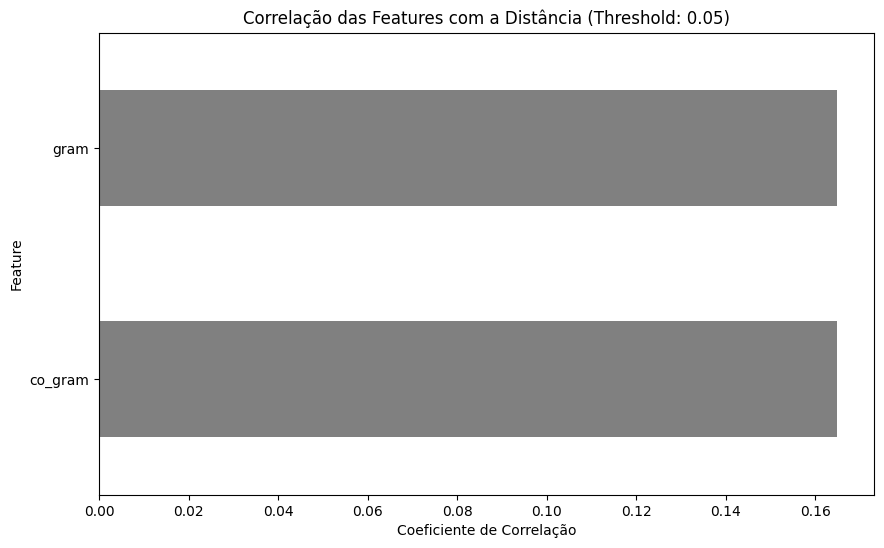

In [6]:
print("--- Method (i): Correlation Ranking ---")
correlations = X.corrwith(y)
threshold = 0.05
sorted_correlation_rank = correlations.abs().sort_values(ascending=False)
top_features = sorted_correlation_rank[sorted_correlation_rank > threshold]

top_features.index.to_series().to_csv("../results/data_analysis_v2/correlation_feature_selection.csv", index=False, header=["feature"])

plot_top_features(
    top_features,
    f"Correlação das Features com a Distância (Threshold: {threshold})",
    "Coeficiente de Correlação",
    "Feature"
)

--- Random Forest Importance Ranking ---


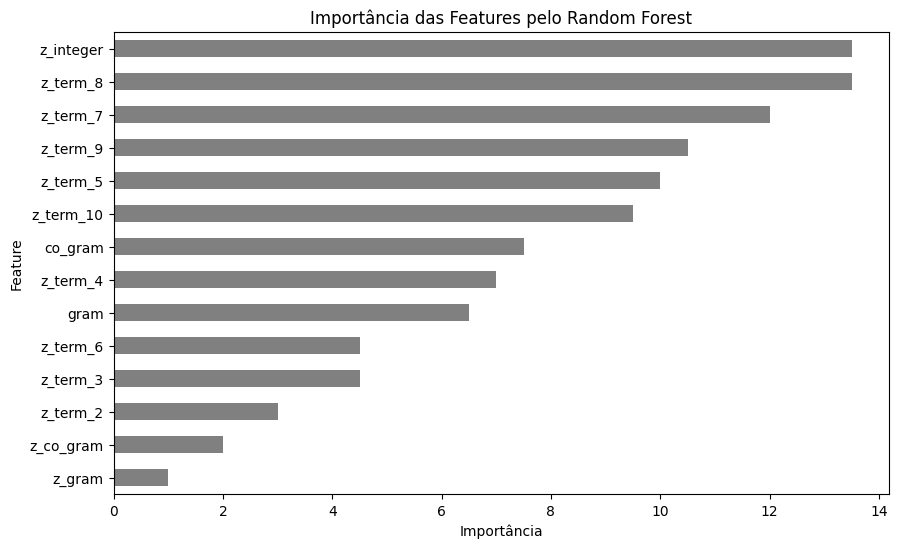

In [7]:
print("--- Random Forest Importance Ranking ---")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

rf_purity = pd.Series(rf_model.feature_importances_, index=X.columns)

perm_result = permutation_importance(rf_model, X, y, n_repeats=10, random_state=42, n_jobs=1)
rf_accuracy = pd.Series(perm_result.importances_mean, index=X.columns)

combined_rank = (rf_purity.rank(ascending=False) + rf_accuracy.rank(ascending=False)) / 2
top_features = combined_rank.nsmallest(20)

result_df = pd.DataFrame({"feature": top_features.sort_values(ascending=False).index})
result_df.to_csv("../results/data_analysis_v2/random_forest_feature_selection.csv", index=False)

plot_top_features(
    top_features,
    "Importância das Features pelo Random Forest",
    "Importância",
    "Feature"
)

--- Method (iii) Neural Network Importance Ranking (Gevrey) ---
z_gram       18.721616
z_co_gram    15.522594
z_term_2     10.082047
co_gram       7.628162
gram          7.583989
z_term_3      6.998371
z_term_4      6.294867
z_term_6      5.662695
z_term_5      4.370038
z_integer     4.220296
z_term_8      4.093146
z_term_9      3.345948
z_term_10     2.951605
z_term_7      2.524626
dtype: float64


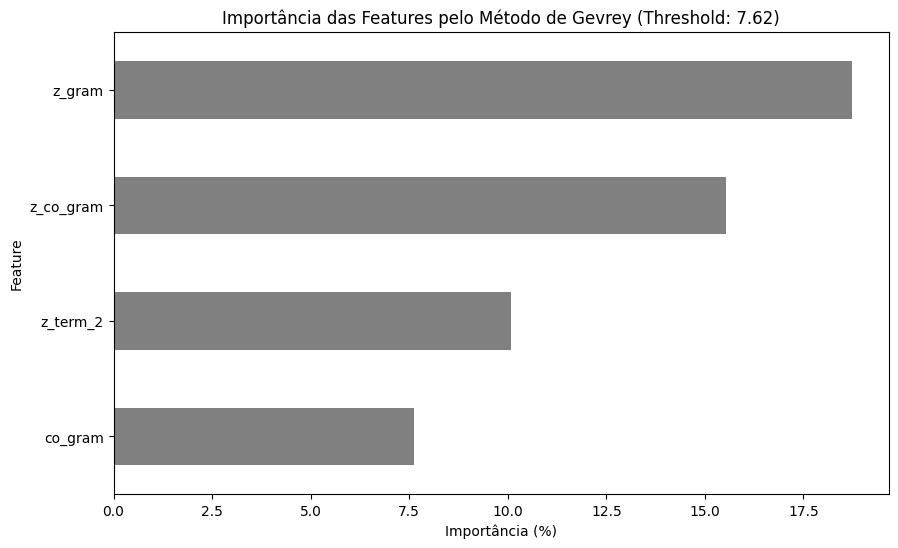

In [8]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("--- Method (iii) Neural Network Importance Ranking (Gevrey) ---")

nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y)

W = nn_model.coefs_[0] # matriz de pesos entre a camada de entrada e a primeira camada oculta
ni = W.shape[0]
nh = W.shape[1]

Q = np.zeros((ni, nh))

for h in range(nh):
    soma_pesos = 0
    for i in range(ni):
        soma_pesos += abs(W[i, h])
    for i in range(ni):
        Q[i, h] = abs(W[i, h]) / soma_pesos

soma_total = 0
for h in range(nh):
    for i in range(ni):
        soma_total += Q[i, h]

RI = np.zeros(ni)

for i in range(ni):
    soma_h = 0
    for h in range(nh):
        soma_h += Q[i, h]
    RI[i] = (soma_h / soma_total) * 100

nn_importance = pd.Series(RI, index=X.columns)
nn_importance_sorted = nn_importance.sort_values(ascending=False)

print(nn_importance_sorted)

threshold_nn = np.percentile(RI, 75)
final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

final_ranked_features.index\
    .to_series()\
    .to_csv("../results/data_analysis_v2/gevrey_method_feature_selection.csv", index=False, header=["feature"])

plot_top_features(
    final_ranked_features,
    f"Importância das Features pelo Método de Gevrey (Threshold: {threshold_nn:.2f})",
    "Importância (%)",
    "Feature"
)

In [9]:
n_features_mrmr = 10
mrmr_selector = MRMR(method="MID", regression=True, max_features=n_features_mrmr)
X_mrmr = mrmr_selector.fit_transform(X, y)
selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
pd.DataFrame({"feature": selected_features}).to_csv(f"../results/data_analysis_v2/mrmr_{n_features_mrmr}_features.csv", index=False)